# Data exploration and documetation of the Norshelf dataset
The following notebook will illustrate the variables and their use. Including shape and how they relate to the domain. 

In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from utils import get_boundary_slice, plot_2boundary_slice
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 18

## Load the data 
For illustration purposes using data from 10th of March 2024 (outer=0).

In [ ]:
year = 2024
month = '03'
day = 10
dir = f'https://thredds.met.no/thredds/dodsC/foccus/'

outer = 0
ds = xr.open_dataset(dir + f'norshelf-ana_fwd_{year}{month}{day}T00Z_outer{outer}.nc')

### Information about the variables and their shape
- `ocean_time`: 17 timesteps. Updated every 3rd hour, starting from 3*16 hours before the time of the filename, e.g. ocean_time[-1]=2024-03-10T00 and ocean_time[0]=2024-03-08T00
- `s_rho`: 42 layers. s-depth coordinate at rho points for all variables, range between (-1, 0)
- variables ending with `_obc` have 5 dimemsions: (`ocean_time`: 17, `obc_adjust`: 17, `boundary`: 4, `s_rho`: 42, `IorJ`: 901)
    - `obc_adjust`: length 17, ?? same length as time dimension, does it give adjusted values?
    - `boundary`: length 4, variable to select boundary, values can be (0,1,2,3)=(south,east,north,west), e.g. counter clock-wise
    - `IorJ`: length 901, index of same length/content as `xi_rho` even if the boundary selected is along `eta_rho` (which is shorter). Convenient for plotting/comparing boundaries. 
- all other variables have 4 dimensions: (`ocean_time`: 17, `s_rho`: 42, `eta_rho`: 351, `xi_rho`: 901)
    - `eta_rho`: length 351, index in lon-direction at rho points, e.g. 0,1,2,..,350
    - `xi_rho`: length 901, index in lat-direction at rho points, e.g. 0,1,2..,900

In [4]:
ds.obc_adjust.values

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16])

# Illustration of the boundaries for the `_obc` variables
Which boundary is which?

In [14]:
# Get the surface salt at time=0 (2024-03-08T00)
salt = ds.salt.isel(ocean_time=0, s_rho=0).values # shape (351, 901)

# Pick out the salt at the four boundaries
salt_bound = np.ones([4,901]) * np.nan
salt_bound[0,:351] = salt[ :, 0] # left y-axis / south (351,)
salt_bound[1,:]    = salt[ 0, :] # bottom x-axis / east (901,)
salt_bound[2,:351] = salt[ :,-1] # right y-axis / north (351,)
salt_bound[3:]     = salt[-1, :] # top x-axis / west (901,)

# The obc values contains a lot of smaller values, let set a threshold at 30
# and put nan for everything < 20
salt_obc = np.empty([4,901])
for i in range(4):
    salt_obc_init = ds.salt_obc.isel(ocean_time=0, s_rho=0, boundary=i, obc_adjust=0).values
    salt_obc[i] = np.where(salt_obc_init > 20,salt_obc_init, np.nan)


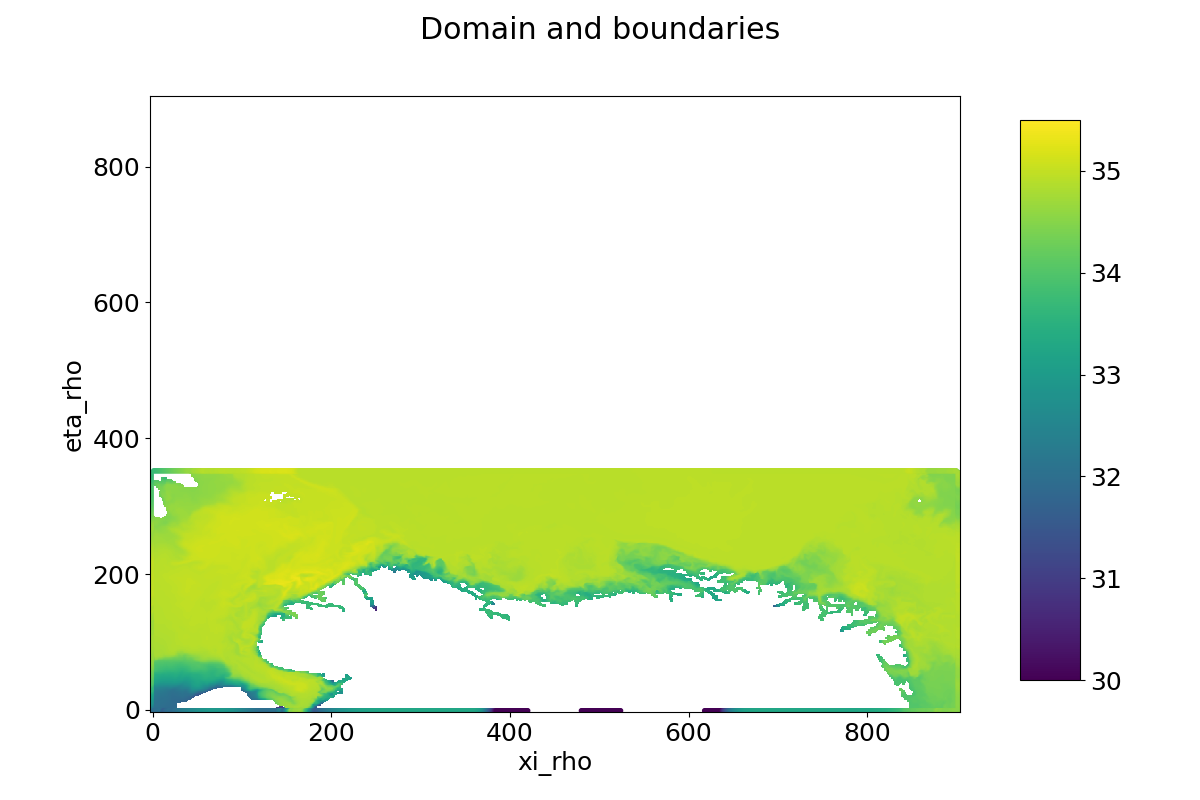

In [15]:
N_x = ds.xi_rho.size
#N_y = ds.eta_rho.size

fig, ax = plt.subplots(1)
fig.suptitle('Domain and boundaries')
ax.set_ylim(-3,N_x+3)
ax.set_xlim(-3,N_x+3)
ax.set_xlabel('xi_rho')
ax.set_ylabel('eta_rho')

# Plot salt
smin= 30
smax = 35.5
im = ax.pcolor(salt,vmin=smin,vmax=smax)

# Plotting (for verification) the bouandaries that was picked out
ax.scatter(np.ones(N_x)*-1,np.arange(N_x),c=salt_bound[0,:],s=8,vmin=smin,vmax=smax) # south 
ax.scatter(np.arange(N_x),np.ones(N_x)*-1,c=salt_bound[1,:],s=8,vmin=smin,vmax=smax) # east
ax.scatter(np.ones(N_x)*902,np.arange(N_x),c=salt_bound[2,:],s=8,vmin=smin,vmax=smax) # north
ax.scatter(np.arange(N_x),np.ones(N_x)*352,c=salt_bound[3,:],s=8,vmin=smin,vmax=smax) # west

# Compare salt and salt_obs at each boundary
# ??? south, east and west have values over land ??? 
ax.scatter(np.ones(N_x)*-2,np.arange(N_x),c=salt_obc[0],s=8,vmin=smin,vmax=smax) # b=0=south
ax.scatter(np.arange(N_x),np.ones(N_x)*-1.1,c=salt_obc[1],s=8,vmin=smin,vmax=smax) # b=3=east 
ax.scatter(np.ones(N_x)*902.1,np.arange(N_x),c=salt_obc[2],s=8,vmin=smin,vmax=smax) # b=2=north
ax.scatter(np.arange(N_x),np.ones(N_x)*352.1,c=salt_obc[3],s=8,vmin=smin,vmax=smax) # b=3=west 

# Add a colorbar
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax)


### Plotting the surface salinity together with `salt_obc` 

Text(0, 0.5, 'Salinity')

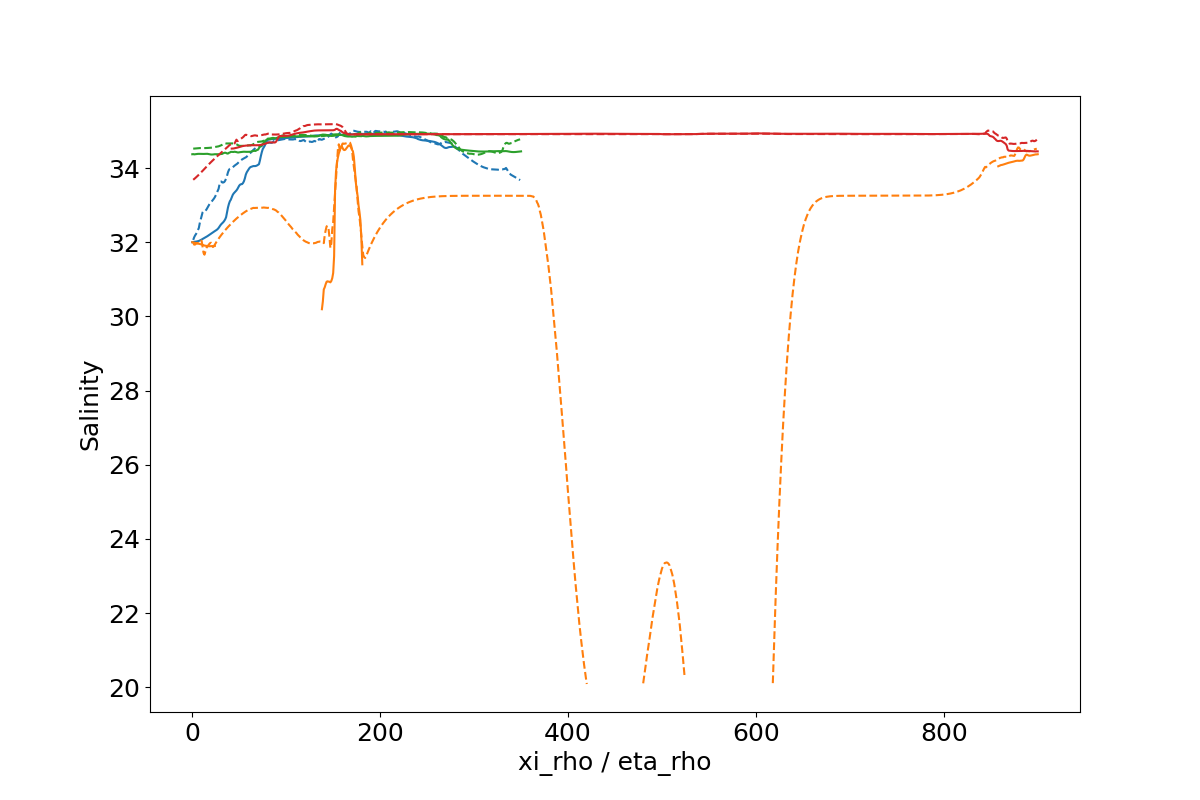

In [16]:
fig0, ax0 = plt.subplots(1)
for i in range(4):
    ax0.plot(ds.xi_rho,salt_bound[i],color=f'C0{i}')
    ax0.plot(ds.xi_rho,salt_obc[i],color=f'C0{i}',linestyle='--')

ax0.set_xlabel('xi_rho / eta_rho')
ax0.set_ylabel('Salinity')

## Plots of western boundary (=3)

Several utility functions can be found in utils.py

In [17]:
# Select which variable to plot
var_name = 'temp'
var_west     = get_boundary_slice(ds,var_name,direction='west')
var_west_obc = get_boundary_slice(ds,var_name,direction='west',obc=True)

# Variable to plot contour lines
cvar_west     = get_boundary_slice(ds,'salt',direction='west')
cvar_west_obc = get_boundary_slice(ds,'salt',direction='west',obc=True)
cmin = cvar_west[np.isfinite(cvar_west)].min() #34.381565 35.13307
cmax = cvar_west[np.isfinite(cvar_west)].max()
clevels = np.linspace(34,35,11)

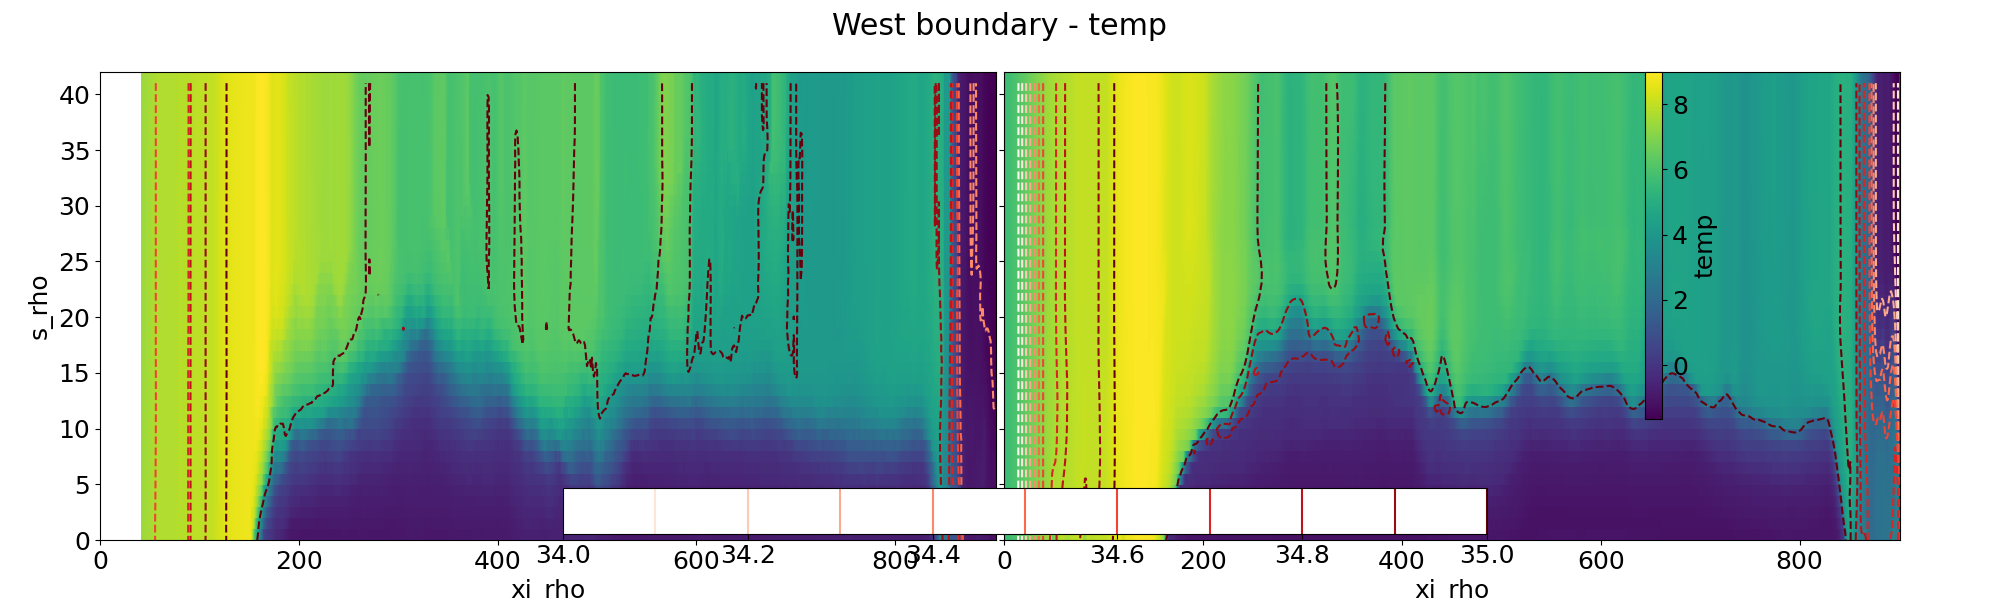

In [ ]:
fig2, axs = plt.subplots(1,2,figsize=(20,6),sharey=True)
(ax1,ax2) = axs
fig2.suptitle(f'West boundary - {var_name}')
ax1.set_xlabel("xi_rho")
ax2.set_xlabel("xi_rho")
ax1.set_ylabel("s_rho")

smin = -2 #31.999
smax = 10 #35.1

im1 = ax1.pcolor(var_west)#,vmin=smin,vmax=smax)#,cmap='cool')
im2 = ax2.pcolor(var_west_obc)#,vmin=smin,vmax=smax)#,cmap='cool')
cn1 = ax1.contour(cvar_west,linestyles='--',cmap='Reds',levels=clevels)
cn1 = ax2.contour(cvar_west_obc,linestyles='--',cmap='Reds',levels=clevels) 

fig2.colorbar(cn1, ax=axs, orientation='horizontal', fraction=.1)
fig2.colorbar(im1, ax=axs, fraction=.1,label=f'{var_name}')

fig2.subplots_adjust(wspace=0.01,left=0.05,right=0.95,bottom=0.1) #left=None, bottom=None, right=None, top=None, wspace=None, hspace=None

### Plot velocity contour lines

In [10]:
# Variable to plot contour lines
cvar_name = 'u'
cvar_west     = get_boundary_slice(ds,cvar_name,direction='west',itime=0) # (42, 901)
cvar_west_obc = get_boundary_slice(ds,cvar_name,direction='west',itime=0,obc=True)
cmin = cvar_west[np.isfinite(cvar_west)].min() #34.381565 35.13307
cmax = cvar_west[np.isfinite(cvar_west)].max()
clevels = [-100,0,100] # negative or positive values

In [11]:
print(cmin,cmax)

-0.3623410165309906 0.4207136929035187


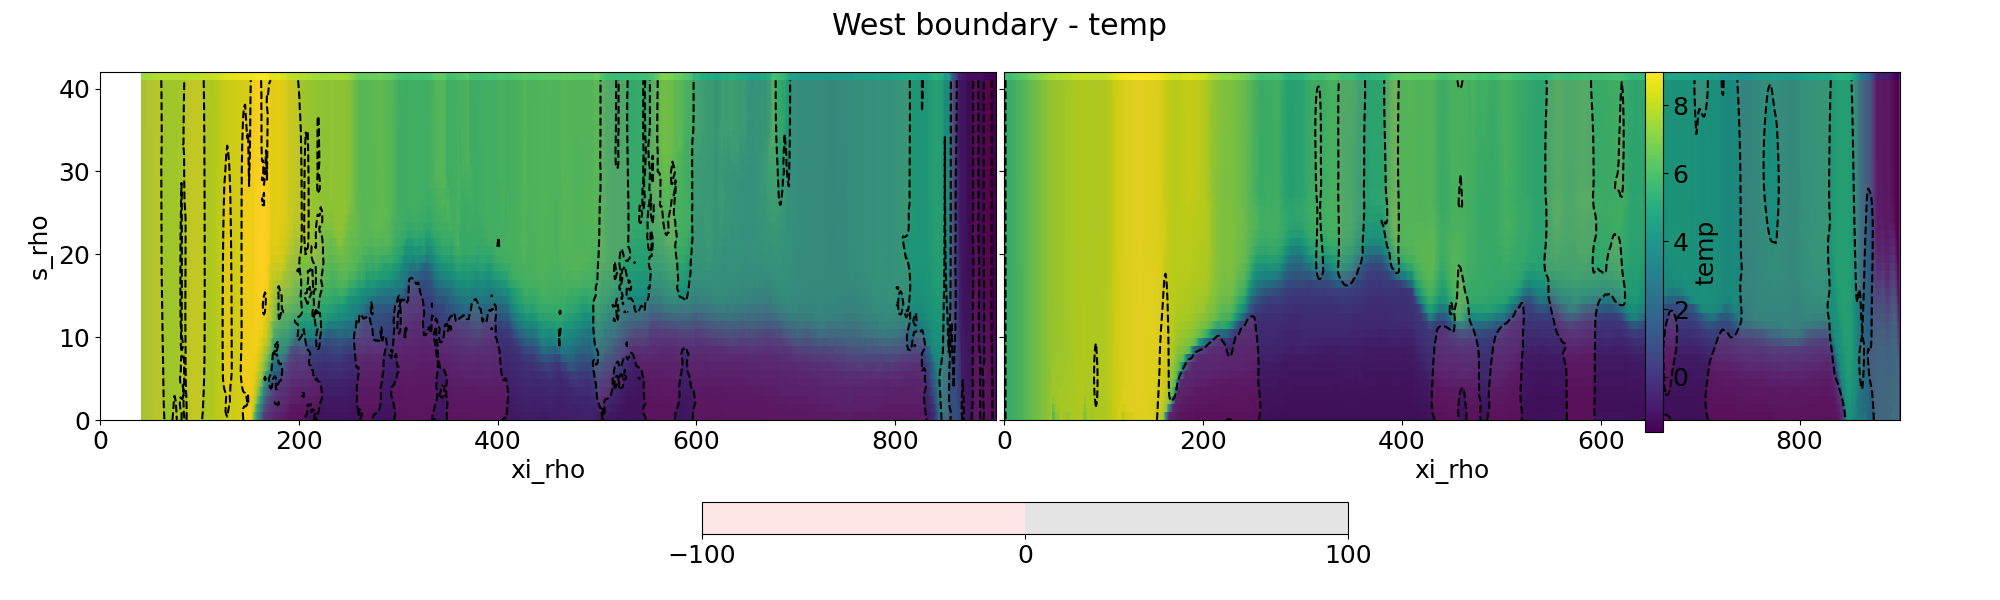

In [12]:
fig3, aks = plt.subplots(1,2,figsize=(20,6),sharey=True)
(ak1,ak2) = aks
fig3.suptitle(f'West boundary - {var_name}')
ak1.set_xlabel("xi_rho")
ak2.set_xlabel("xi_rho")
ak1.set_ylabel("s_rho")

smin = -2 #31.999
smax = 10 #35.1

i1 = ak1.pcolor(var_west)#,vmin=smin,vmax=smax)#,cmap='cool')
i2 = ak2.pcolor(var_west_obc)#,vmin=smin,vmax=smax)#,cmap='cool')
cf1 = ak1.contourf(cvar_west,levels=clevels,colors=['r','k'],alpha=0.1)
cf1 = ak2.contourf(cvar_west_obc,linestyles='--',levels=clevels,colors=['r','k'],alpha=0.1) 
c1 = ak1.contour(cvar_west,linestyles='--',levels=clevels,colors=['r','k'])
c1 = ak2.contour(cvar_west_obc,linestyles='--',levels=clevels,colors=['r','k']) 

fig3.colorbar(cf1, ax=aks, orientation='horizontal', fraction=.07) #
#fig3.colorbar(c1, ax=aks, orientation='horizontal', fraction=.07) #
fig3.colorbar(i1, ax=aks, fraction=.1,label=f'{var_name}')

fig3.subplots_adjust(wspace=0.01,left=0.05,right=0.95,bottom=0.3) #left=None, bottom=None, right=None, top=None, wspace=None, hspace=None

## What does `obc_adjust` do?
Does it give the correction between salt and salt_obc? Make a plot
adjust=1 gives very small values?? Check other parameters than salt too. 

In [ ]:
ds.salt_obc.isel(ocean_time=0, s_rho=0, boundary=0, obc_adjust=1).values - ds.salt_obc.isel(ocean_time=0, s_rho=0, boundary=0, obc_adjust=0).values

array([  0.      , -32.061974, -32.13195 , -32.183243, -32.220833,
       -32.268883, -32.325867, -32.385162, -32.51715 , -32.610954,
       -32.708893, -32.807274, -32.842365, -32.83906 , -32.8472  ,
       -32.87783 , -32.923256, -32.97124 , -33.01323 , -33.050407,
       -33.082138, -33.109215, -33.140717, -33.174385, -33.21425 ,
       -33.262142, -33.314674, -33.382027, -33.438786, -33.55941 ,
       -33.63144 , -33.635914, -33.60912 , -33.610416, -33.62223 ,
       -33.6584  , -33.717373, -33.790916, -33.88539 , -33.94902 ,
       -33.980972, -33.9936  , -34.002724, -34.017838, -34.040962,
       -34.064415, -34.082718, -34.098892, -34.11971 , -34.146927,
       -34.17209 , -34.192657, -34.214542, -34.231567, -34.246643,
       -34.263306, -34.27572 , -34.287895, -34.307877, -34.332893,
       -34.358932, -34.383553, -34.40856 , -34.434788, -34.461422,
       -34.489418, -34.510796, -34.53166 , -34.550446, -34.564045,
       -34.577293, -34.590202, -34.59693 , -34.58376 , -34.595